# Refinement vs Cellpose — evaluation

Compares `flow_membrane_seg.py` output against the Cellpose masks it was built from.

**Run this with the `mohit` kernel** (needs `skimage`, `pandas`, `matplotlib`).
`cellpose2` does not have them.

Inputs it expects:

| file | from | holds |
|---|---|---|
| `<stem>_seg.npy` | `Run_cellpose.py` | `img`, `flows`, `masks` (the Cellpose baseline) |
| `<stem>_seg.whole_cell.tif` | `flow_membrane_seg.py` | refined labels |
| `<stem>_seg.cells.csv` | `flow_membrane_seg.py` | per-cell QC table |

## 1. Config

In [1]:
from pathlib import Path

# --- EDIT THESE -------------------------------------------------------------
CELLPOSE_DIR = Path("/omics/odcf/analysis/OE0622_projects/mibi_shared/Amir/preprocessing/segmentation/positivity_map_v3/sorted_by_quality/High/whole_cell/TN2_hiRes_Amir_posMap2")   # holds *_seg.npy
REFINED_DIR  = CELLPOSE_DIR / "flow_membrane"                # holds *.whole_cell.tif
# ----------------------------------------------------------------------------

MATCH_IOU = 0.3    # min IoU to call a Cellpose cell and a refined cell the same cell
AREA_TOL  = 0.10   # +/- this fraction of area still counts as "same size"

# seg['img'] plane order. Run_cellpose.py stores (membrane, nucleus),
# because Cellpose wants the membrane in its primary channel slot.
# Section 7 prints a check; swap these if it disagrees.
MEMBRANE_PLANE = 0
NUCLEUS_PLANE  = 1

# Which FOV the example figures use: an index into `pairs`,
# or part of a stem, e.g. "A_1a_C01_R01_p2".
FOV = "C_3a_C01_R01"

In [2]:
import numpy as np
import pandas as pd
import tifffile as tiff
import matplotlib.pyplot as plt
from scipy import sparse
from skimage.segmentation import find_boundaries

plt.rcParams["figure.dpi"] = 110

## 2. Pair up the files

In [3]:
def find_pairs(cellpose_dir=None, refined_dir=None):
    """Match each Cellpose _seg.npy to its refined .whole_cell.tif by stem."""
    cellpose_dir = Path(cellpose_dir or CELLPOSE_DIR)
    refined_dir  = Path(refined_dir  or REFINED_DIR)

    pairs = []
    for seg in sorted(cellpose_dir.glob("*_seg.npy")):
        stem = seg.stem                                  # e.g. A_1a_..._seg
        ref  = refined_dir / f"{stem}.whole_cell.tif"
        csv  = refined_dir / f"{stem}.cells.csv"
        if ref.exists():
            pairs.append(dict(stem=stem, seg=seg, refined=ref,
                              csv=csv if csv.exists() else None))
    return pairs

pairs = find_pairs()
print(f"{len(pairs)} paired FOVs")
if not pairs:
    print("No pairs. Check CELLPOSE_DIR / REFINED_DIR, and that the refinement has run.")
for p in pairs[:5]:
    print(" ", p["stem"])

149 paired FOVs
  A_1a_C01_R01_p2_seg
  A_1c_C01_R01_p2_seg
  A_1d_C01_R01_p2_seg
  A_2c_C01_R01_p2_seg
  A_2h_C01_R01_p2_seg


In [4]:
def load_pair(p):
    """Return (img, cellpose_labels, refined_labels, per-cell table or None)."""
    d = np.load(p["seg"], allow_pickle=True).item()
    img = np.asarray(d["img"]).astype(np.float32)
    cp  = np.asarray(d["masks"]).astype(np.int32) if d.get("masks") is not None else None
    ref = tiff.imread(str(p["refined"])).astype(np.int32)
    tab = pd.read_csv(p["csv"]) if p["csv"] else None
    return img, cp, ref, tab

## 3. Per-FOV summary

Counts and areas for both segmentations. `frac_covered` is the share of the frame
assigned to any cell — a quick read on whether the refinement is shrinking or
growing masks overall.

In [5]:
def label_stats(lab, prefix):
    ids, cnt = np.unique(lab[lab > 0], return_counts=True)
    if len(cnt) == 0:
        return {f"{prefix}_n": 0, f"{prefix}_median_area": 0, f"{prefix}_frac": 0.0}
    return {
        f"{prefix}_n": len(ids),
        f"{prefix}_median_area": int(np.median(cnt)),
        f"{prefix}_frac": round(float(cnt.sum()) / lab.size, 4),
    }

rows = []
for p in pairs:
    img, cp, ref, tab = load_pair(p)
    r = {"stem": p["stem"]}
    if cp is not None:
        r.update(label_stats(cp, "cellpose"))
    r.update(label_stats(ref, "refined"))
    if tab is not None and "low_confidence" in tab:
        r["low_conf"] = int(tab["low_confidence"].sum())
    rows.append(r)

summary = pd.DataFrame(rows)
if len(summary) and "cellpose_n" in summary:
    summary["delta_n"] = summary["refined_n"] - summary["cellpose_n"]
summary

,stem,cellpose_n,cellpose_median_area,cellpose_frac,refined_n,refined_median_area,refined_frac,low_conf,delta_n
0,A_1a_C01_R01_p2_seg,210,10790,0.5924,118,8899,0.3915,7,-92
1,A_1c_C01_R01_p2_seg,252,5724,0.3872,212,5664,0.3817,1,-40
2,A_1d_C01_R01_p2_seg,292,10299,0.8138,111,9193,0.3742,1,-181
3,A_2c_C01_R01_p2_seg,161,12169,0.5505,135,8209,0.3853,6,-26
4,A_2h_C01_R01_p2_seg,41,9650,0.1218,85,5505,0.1601,25,44
...,...,...,...,...,...,...,...,...,...
144,E_5a_C01_R01_p2_seg,537,6718,0.9816,566,5827,0.9961,0,29
145,E_5c_C01_R01_seg,127,12924,0.4934,145,9279,0.4479,6,18
146,E_6a_C01_R01_p2_seg,119,16525,0.5229,128,9899,0.4543,3,9
147,E_6a_C01_R01_seg,64,14025,0.2608,85,10444,0.3231,24,21


In [6]:
if len(summary):
    display(summary.describe().T[["mean", "50%", "min", "max"]])

,mean,50%,min,max
cellpose_n,157.536913,141.0000,13.0000,537.0000
cellpose_median_area,10214.563758,10160.0000,4246.0000,21036.0000
cellpose_frac,0.394548,0.3872,0.0359,0.9816
refined_n,178.167785,145.0000,18.0000,566.0000
refined_median_area,6874.395973,6935.0000,1552.0000,16058.0000
refined_frac,0.385008,0.3775,0.0478,0.9961
low_conf,9.449664,9.0000,0.0000,36.0000
delta_n,20.630872,24.0000,-181.0000,131.0000


## 4. Cell counts, Cellpose vs refined

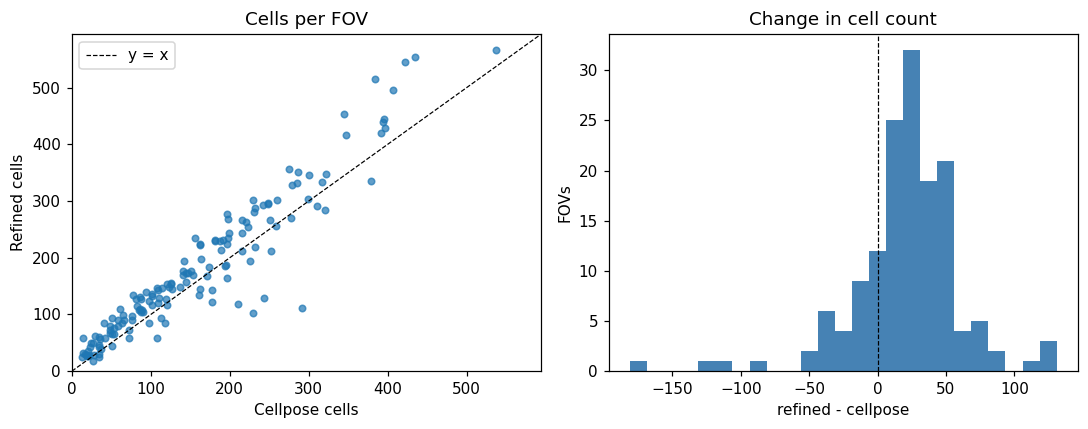

In [7]:
if len(summary) and "cellpose_n" in summary:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].scatter(summary["cellpose_n"], summary["refined_n"], s=18, alpha=.7)
    lim = [0, max(summary["cellpose_n"].max(), summary["refined_n"].max()) * 1.05]
    ax[0].plot(lim, lim, "k--", lw=.8, label="y = x")
    ax[0].set(xlabel="Cellpose cells", ylabel="Refined cells", xlim=lim, ylim=lim,
              title="Cells per FOV")
    ax[0].legend()

    ax[1].hist(summary["delta_n"], bins=25, color="steelblue")
    ax[1].axvline(0, color="k", ls="--", lw=.8)
    ax[1].set(xlabel="refined - cellpose", ylabel="FOVs", title="Change in cell count")
    plt.tight_layout()

## 5. Cell-area distributions

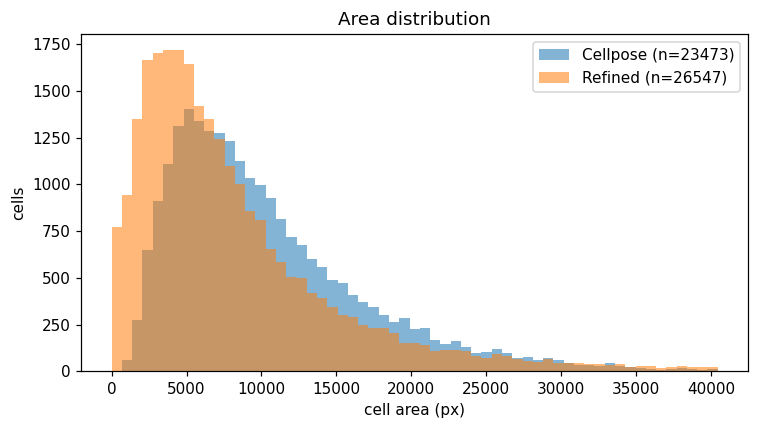

In [8]:
def areas(lab):
    _, c = np.unique(lab[lab > 0], return_counts=True)
    return c

cp_areas, ref_areas = [], []
for p in pairs:
    _, cp, ref, _ = load_pair(p)
    if cp is not None:
        cp_areas.append(areas(cp))
    ref_areas.append(areas(ref))

cp_areas  = np.concatenate(cp_areas)  if cp_areas  else np.array([])
ref_areas = np.concatenate(ref_areas) if ref_areas else np.array([])

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, np.percentile(np.concatenate([cp_areas, ref_areas]), 99), 60)
if len(cp_areas):
    ax.hist(cp_areas, bins=bins, alpha=.55, label=f"Cellpose (n={len(cp_areas)})")
ax.hist(ref_areas, bins=bins, alpha=.55, label=f"Refined (n={len(ref_areas)})")
ax.set(xlabel="cell area (px)", ylabel="cells", title="Area distribution")
ax.legend()
plt.tight_layout()

## 6. What actually changed — cell matching

Each Cellpose cell is matched to at most one refined cell, optimally, by IoU
(`scipy.optimize.linear_sum_assignment`). Every cell then falls into one of:

- **same** — matched, area within ±`AREA_TOL`
- **expanded** — matched, but the refined mask is larger
- **shrunk** — matched, but the refined mask is smaller
- **lost** — a Cellpose cell with no refined counterpart (removed, e.g. as holey)
- **gained** — a refined cell with no Cellpose counterpart

*Why no "split" / "merged":* above IoU 0.5 they cannot occur. A cell whose overlap
exceeds half the union cannot do that with two disjoint cells at once, so those
counts are always 0 — an artefact of the threshold, not a result. One-to-one
matching at a lower `MATCH_IOU` plus an area comparison says what actually happened.

In [9]:
from scipy.optimize import linear_sum_assignment


def iou_matrix(a, b):
    """Dense IoU between label images a and b (labels 1..N, 0 = background)."""
    na, nb = int(a.max()), int(b.max())
    if na == 0 or nb == 0:
        return np.zeros((na, nb))
    m = (a > 0) & (b > 0)
    inter = sparse.coo_matrix(
        (np.ones(int(m.sum()), np.float32), (a[m] - 1, b[m] - 1)),
        shape=(na, nb),
    ).toarray()
    area_a = np.bincount(a.ravel(), minlength=na + 1)[1:].astype(np.float32)
    area_b = np.bincount(b.ravel(), minlength=nb + 1)[1:].astype(np.float32)
    return inter / np.maximum(area_a[:, None] + area_b[None, :] - inter, 1)


def match_cells(cp, ref, thr=None):
    """Optimal one-to-one matching. Returns (matched pairs df, n_lost, n_gained)."""
    thr = MATCH_IOU if thr is None else thr
    cols = ["cp_label", "ref_label", "iou", "area_cellpose", "area_refined", "area_ratio"]
    na, nb = int(cp.max()), int(ref.max())
    if na == 0 or nb == 0:
        return pd.DataFrame(columns=cols), na, nb

    M = iou_matrix(cp, ref)
    r, c = linear_sum_assignment(-M)              # maximise total IoU
    keep = M[r, c] >= thr                         # drop pairings that are not real matches
    r, c = r[keep], c[keep]

    area_cp  = np.bincount(cp.ravel(),  minlength=na + 1)[1:]
    area_ref = np.bincount(ref.ravel(), minlength=nb + 1)[1:]
    df = pd.DataFrame({
        "cp_label": r + 1, "ref_label": c + 1, "iou": M[r, c],
        "area_cellpose": area_cp[r], "area_refined": area_ref[c],
    })
    df["area_ratio"] = df["area_refined"] / np.maximum(df["area_cellpose"], 1)
    return df, na - len(r), nb - len(c)


def summarize(df, n_lost, n_gained, tol=None):
    tol = AREA_TOL if tol is None else tol
    lo, hi = 1 - tol, 1 + tol
    ratio = df["area_ratio"] if len(df) else pd.Series(dtype=float)
    return {
        "matched":  len(df),
        "same":     int(((ratio >= lo) & (ratio <= hi)).sum()),
        "expanded": int((ratio > hi).sum()),
        "shrunk":   int((ratio < lo).sum()),
        "lost":     int(n_lost),
        "gained":   int(n_gained),
        "median_iou":   round(float(ratio.size and df["iou"].median()), 3) if len(df) else 0.0,
        "median_ratio": round(float(ratio.median()), 3) if len(df) else 0.0,
    }


match_rows, all_pairs = [], []
for p in pairs:
    _, cp, ref, _ = load_pair(p)
    if cp is None:
        continue
    df, n_lost, n_gained = match_cells(cp, ref)
    df["stem"] = p["stem"]
    all_pairs.append(df)
    match_rows.append({"stem": p["stem"], **summarize(df, n_lost, n_gained)})

matches   = pd.DataFrame(match_rows)
matched_df = pd.concat(all_pairs, ignore_index=True) if all_pairs else pd.DataFrame()
matches

,stem,matched,same,expanded,shrunk,lost,gained,median_iou,median_ratio
0,A_1a_C01_R01_p2_seg,80,25,34,21,130,38,0.742,1.051
1,A_1c_C01_R01_p2_seg,169,94,42,33,83,43,0.843,0.992
2,A_1d_C01_R01_p2_seg,95,47,30,18,197,16,0.810,0.974
3,A_2c_C01_R01_p2_seg,87,32,19,36,74,48,0.791,0.918
4,A_2h_C01_R01_p2_seg,35,13,10,12,6,50,0.758,1.025
...,...,...,...,...,...,...,...,...,...
144,E_5a_C01_R01_p2_seg,474,234,101,139,63,92,0.814,0.972
145,E_5c_C01_R01_seg,96,32,35,29,31,49,0.731,1.007
146,E_6a_C01_R01_p2_seg,81,19,24,38,38,47,0.696,0.909
147,E_6a_C01_R01_seg,40,11,19,10,24,45,0.699,1.089


MATCH_IOU=0.3  AREA_TOL=+/-10%
same        7281
expanded    4561
shrunk      6217
lost        5414
gained      8488

matched pairs: 18059 | median IoU 0.769 | median area ratio 0.967


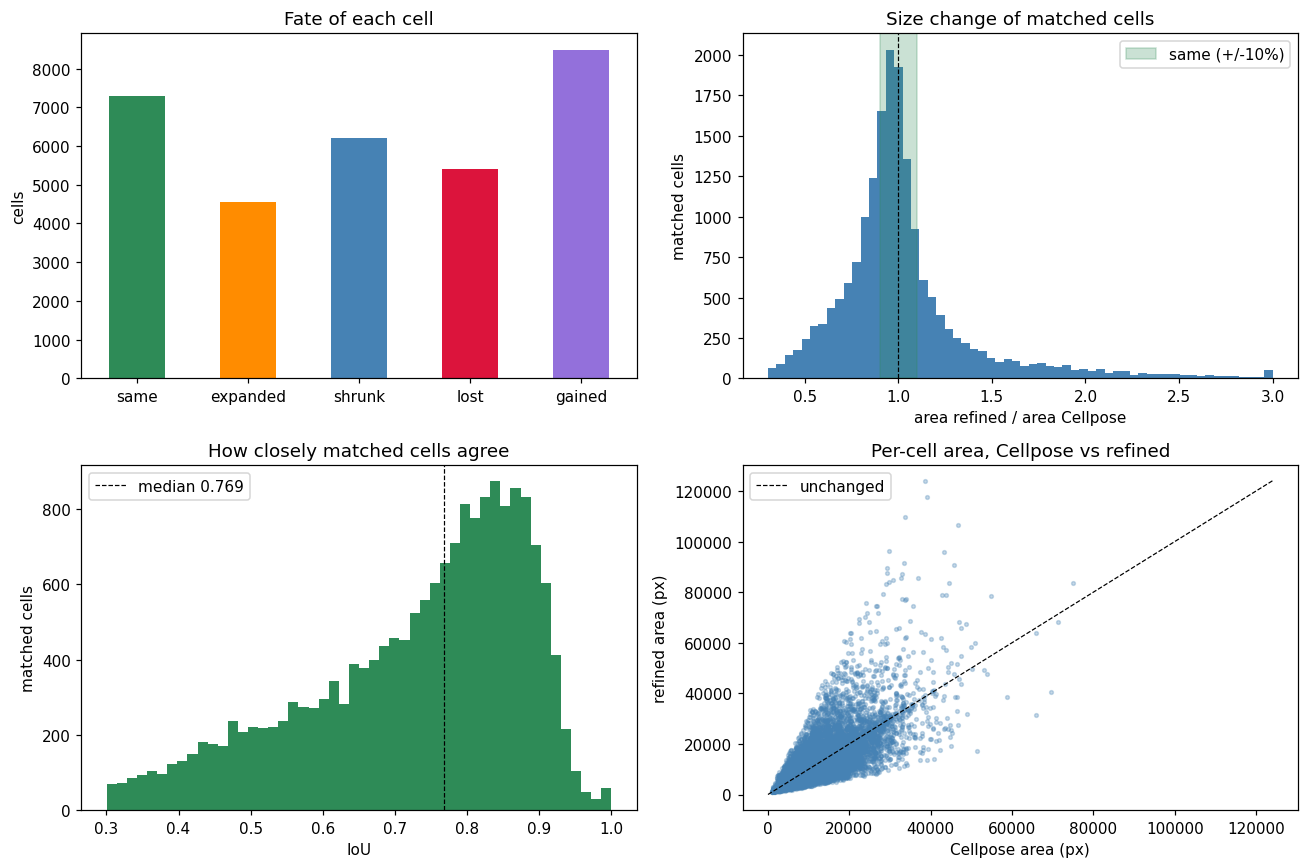

In [10]:
if len(matches):
    tot = matches[["same", "expanded", "shrunk", "lost", "gained"]].sum()
    print(f"MATCH_IOU={MATCH_IOU}  AREA_TOL=+/-{AREA_TOL:.0%}")
    print(tot.to_string())
    print(f"\nmatched pairs: {len(matched_df)} | median IoU "
          f"{matched_df['iou'].median():.3f} | median area ratio "
          f"{matched_df['area_ratio'].median():.3f}")

    fig, ax = plt.subplots(2, 2, figsize=(12, 8))

    # fate of every cell
    tot.plot.bar(ax=ax[0, 0], color=["seagreen", "darkorange", "steelblue",
                                     "crimson", "mediumpurple"], rot=0)
    ax[0, 0].set(ylabel="cells", title="Fate of each cell")

    # how much the matched masks changed size
    lo, hi = 1 - AREA_TOL, 1 + AREA_TOL
    r = matched_df["area_ratio"].clip(0.2, 3.0)
    ax[0, 1].hist(r, bins=60, color="steelblue")
    ax[0, 1].axvspan(lo, hi, color="seagreen", alpha=.25, label=f"same (+/-{AREA_TOL:.0%})")
    ax[0, 1].axvline(1.0, color="k", ls="--", lw=.8)
    ax[0, 1].set(xlabel="area refined / area Cellpose", ylabel="matched cells",
                 title="Size change of matched cells")
    ax[0, 1].legend()

    # agreement of the matched pairs
    ax[1, 0].hist(matched_df["iou"], bins=50, color="seagreen")
    ax[1, 0].axvline(matched_df["iou"].median(), color="k", ls="--", lw=.8,
                     label=f"median {matched_df['iou'].median():.3f}")
    ax[1, 0].set(xlabel="IoU", ylabel="matched cells",
                 title="How closely matched cells agree")
    ax[1, 0].legend()

    # area vs area
    ax[1, 1].scatter(matched_df["area_cellpose"], matched_df["area_refined"],
                     s=6, alpha=.3, color="steelblue")
    m = float(max(matched_df["area_cellpose"].max(), matched_df["area_refined"].max()))
    ax[1, 1].plot([0, m], [0, m], "k--", lw=.8, label="unchanged")
    ax[1, 1].set(xlabel="Cellpose area (px)", ylabel="refined area (px)",
                 title="Per-cell area, Cellpose vs refined")
    ax[1, 1].legend()

    plt.tight_layout()

## 7. Visual check

Counts and IoU tables narrow things down; they can't tell you whether a split was
*correct*. Look at the masks.

C_3a_C01_R01_seg: boundary/interior  img[0]=1.82  img[1]=0.71
  -> membrane looks like img[0]; configured MEMBRANE_PLANE=0


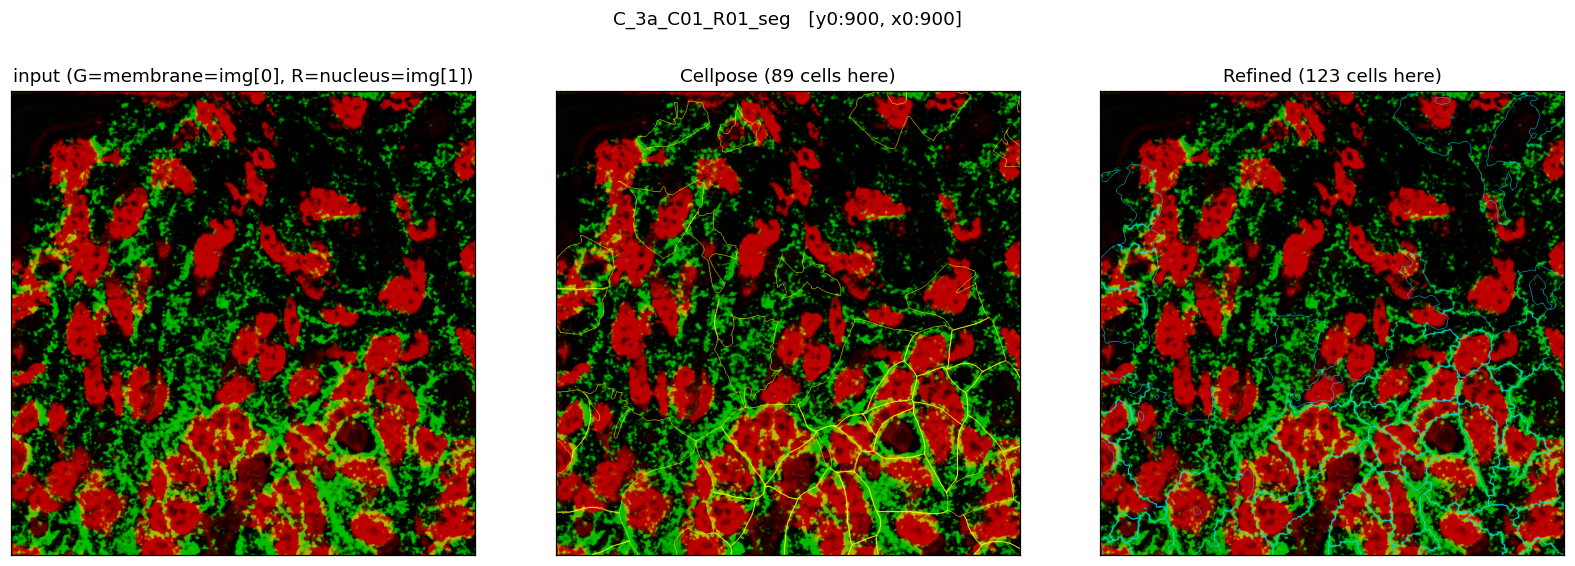

In [11]:
def get_pair(sel=None):
    """Pick a FOV by index, or by (part of) its stem."""
    sel = FOV if sel is None else sel
    if isinstance(sel, (int, np.integer)):
        return pairs[int(sel)]
    hits = [p for p in pairs if str(sel) in p["stem"]]
    if not hits:
        raise KeyError(f"No FOV matching {sel!r}. Have: {[p['stem'] for p in pairs][:8]}")
    return hits[0]


def show_pair(p=None, crop=None, size=512, dim=0.75):
    """RGB input with Cellpose (yellow) and refined (cyan) boundaries overlaid."""
    if p is None or isinstance(p, (int, np.integer, str)):
        p = get_pair(p)
    img, cp, ref, _ = load_pair(p)
    H, W = img.shape[-2:]
    if crop is None:
        y0 = x0 = 0
        s = min(size, H, W)
    else:
        y0, x0, s = crop
    # clamp to the frame, so an out-of-range crop shrinks instead of coming back empty
    y0 = max(0, min(int(y0), H - 1))
    x0 = max(0, min(int(x0), W - 1))
    s  = max(1, min(int(s), H - y0, W - x0))
    sl = np.s_[y0:y0 + s, x0:x0 + s]

    # Index the planes explicitly: seg['img'] is (membrane, nucleus), so taking
    # img[0] as "nucleus" would paint the membrane red.
    mem = img[MEMBRANE_PLANE][sl]
    nuc = img[NUCLEUS_PLANE][sl]
    rgb = np.zeros((s, s, 3), np.float32)
    rgb[..., 1] = np.clip(mem, 0, 1) * dim      # membrane -> GREEN
    rgb[..., 0] = np.clip(nuc, 0, 1) * dim      # nucleus  -> RED

    fig, ax = plt.subplots(1, 3, figsize=(15, 5.2), sharex=True, sharey=True)
    ax[0].imshow(rgb)
    ax[0].set_title(f"input (G=membrane=img[{MEMBRANE_PLANE}], "
                    f"R=nucleus=img[{NUCLEUS_PLANE}])")

    a = rgb.copy()
    if cp is not None:
        a[find_boundaries(cp[sl], mode="inner")] = [1, 1, 0]
    ax[1].imshow(a)
    ax[1].set_title(f"Cellpose ({0 if cp is None else cp[sl].max()} cells here)")

    b = rgb.copy()
    b[find_boundaries(ref[sl], mode="inner")] = [0, .86, 1]
    ax[2].imshow(b); ax[2].set_title(f"Refined ({ref[sl].max()} cells here)")

    for a_ in ax:
        a_.set_xticks([]); a_.set_yticks([])
    fig.suptitle(f"{p['stem']}   [y{y0}:{y0+s}, x{x0}:{x0+s}]")
    plt.tight_layout(rect=[0, 0, 1, 0.93])


def check_channels(p=None):
    """Membrane is bright on cell boundaries and dim inside; nucleus is flatter."""
    from scipy import ndimage as ndi
    p = get_pair(p) if not isinstance(p, dict) else p
    img, cp, ref, _ = load_pair(p)
    lab = cp if cp is not None else ref
    bnd  = find_boundaries(lab, mode="inner") & (lab > 0)
    core = ndi.binary_erosion(lab > 0, np.ones((9, 9)))
    r = [float(img[i][bnd].mean() / max(img[i][core].mean(), 1e-9)) for i in (0, 1)]
    print(f"{p['stem']}: boundary/interior  img[0]={r[0]:.2f}  img[1]={r[1]:.2f}")
    print(f"  -> membrane looks like img[{0 if r[0] > r[1] else 1}]; "
          f"configured MEMBRANE_PLANE={MEMBRANE_PLANE}")
    return r


if pairs:
    check_channels()
    show_pair(size=900)

### Overlaid comparison

Both segmentations on the same image: **yellow = Cellpose**, **cyan dashed = refined**.
Where they agree the cyan sits directly on the yellow, so disagreements are what stands out.

`show_fov_and_zoom()` draws the whole FOV plus a zoom, and marks the zoom region
on the full view. The `_seg.npy` is read once and shared by both panels.

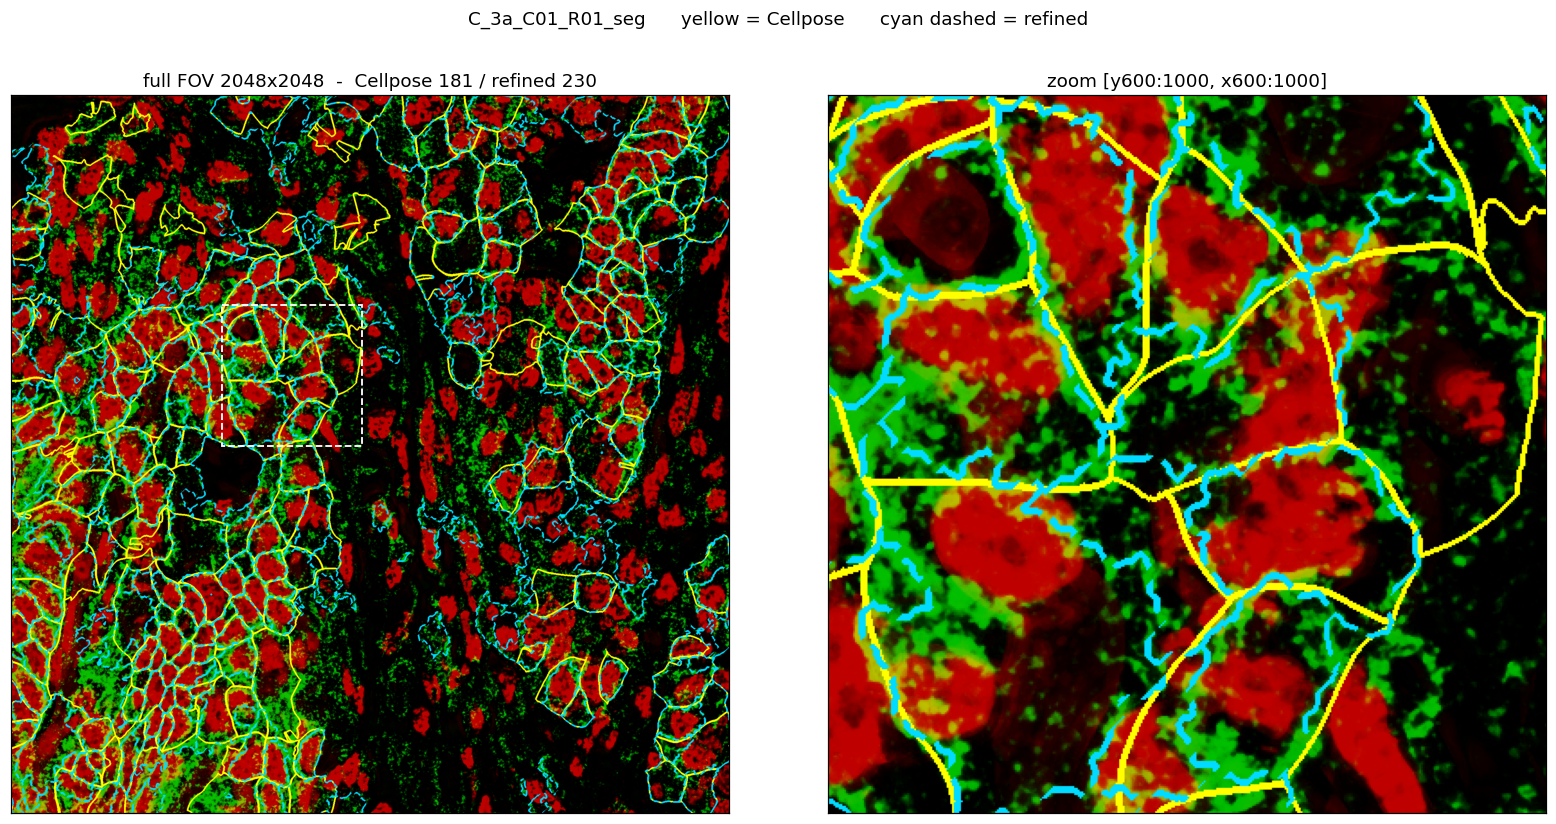

In [12]:
from skimage.morphology import dilation, disk
from matplotlib.patches import Rectangle


def _rgb(img, sl, dim=0.75):
    """Input as RGB: membrane -> green, nucleus -> red."""
    mem = np.clip(img[MEMBRANE_PLANE][sl], 0, 1)
    nuc = np.clip(img[NUCLEUS_PLANE][sl], 0, 1)
    out = np.zeros(mem.shape + (3,), np.float32)
    out[..., 1] = mem * dim
    out[..., 0] = nuc * dim
    return out


def _draw(ax, img, cp, ref, sl, width=2, dashed=True, dim=0.75, title=""):
    rgb = _rgb(img, sl, dim)
    h, w = rgb.shape[:2]

    if cp is not None:
        cb = dilation(find_boundaries(cp[sl], mode="inner"), disk(width))
        rgb[cb] = [1.0, 1.0, 0.0]                      # Cellpose: solid yellow

    fb = dilation(find_boundaries(ref[sl], mode="inner"), disk(width))
    if dashed:
        Y, X = np.mgrid[0:h, 0:w]
        fb = fb & (((X + Y) % 30) < 22)                # dashed, so overlaps stay readable
    rgb[fb] = [0.0, 0.86, 1.0]                         # refined: cyan

    ax.imshow(np.clip(rgb, 0, 1))
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])


def _auto_width(span):
    """Contour thickness in source pixels, so both panels look the same on screen."""
    return max(1, int(round(span / 1000)))


def show_fov_and_zoom(sel=None, crop=None, zoom=512,
                      width_full=None, width_zoom=None, dim=0.75, dashed=True,
                      figsize=(15, 7.6)):
    """Full FOV + a zoom, with Cellpose (yellow) and refined (cyan dashed) overlaid."""
    p = get_pair(sel)
    img, cp, ref, _ = load_pair(p)          # read the 165 MB npy once, use twice
    H, W = img.shape[-2:]

    if crop is None:                        # default: centre square
        s = min(zoom, H, W)
        y0, x0 = (H - s) // 2, (W - s) // 2
    else:
        y0, x0, s = crop
    y0 = max(0, min(int(y0), H - 1))
    x0 = max(0, min(int(x0), W - 1))
    s  = max(1, min(int(s), H - y0, W - x0))

    # a fixed width looks hairline on the full FOV and enormous in the zoom
    wf = _auto_width(max(H, W)) if width_full is None else width_full
    wz = _auto_width(s)         if width_zoom is None else width_zoom

    n_cp  = 0 if cp is None else int(cp.max())
    n_ref = int(ref.max())

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    _draw(ax[0], img, cp, ref, np.s_[0:H, 0:W], wf, dashed, dim,
          f"full FOV {H}x{W}  -  Cellpose {n_cp} / refined {n_ref}")
    ax[0].add_patch(Rectangle((x0, y0), s, s, fill=False, ec="white", lw=1.2, ls="--"))

    _draw(ax[1], img, cp, ref, np.s_[y0:y0 + s, x0:x0 + s], wz, dashed, dim,
          f"zoom [y{y0}:{y0+s}, x{x0}:{x0+s}]")

    fig.suptitle(f"{p['stem']}      yellow = Cellpose      cyan dashed = refined",
                 fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    return fig


if pairs:
    show_fov_and_zoom(crop=(600, 600, 400))

## 8. Per-cell QC table

From `*.cells.csv`. `low_confidence` flags cells with both a weak boundary
membrane and little nuclear content.

26547 cells | low confidence: 1408 (5.3%)


,label,area_px,boundary_membrane,nuclear_frac,mean_cellprob,sink_strength,low_confidence,stem
0,1,3579,0.2126,0.3398,0.8907,0.1281,0,A_1a_C01_R01_p2_seg
1,2,107,0.4355,0.6916,0.6593,0.1590,0,A_1a_C01_R01_p2_seg
2,3,4957,0.8584,0.0482,1.4540,0.1684,0,A_1a_C01_R01_p2_seg
3,4,6537,0.7853,0.5484,2.1833,0.7008,0,A_1a_C01_R01_p2_seg
4,5,16799,0.6109,0.3431,0.7888,0.1691,0,A_1a_C01_R01_p2_seg


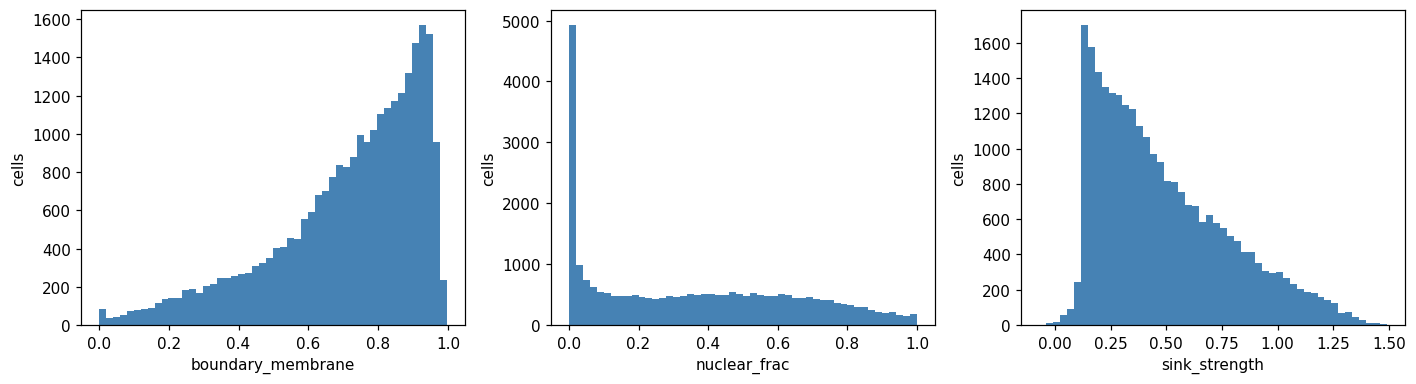

In [13]:
tabs = []
for p in pairs:
    if p["csv"]:
        t = pd.read_csv(p["csv"])
        t["stem"] = p["stem"]
        tabs.append(t)

if tabs:
    cells_df = pd.concat(tabs, ignore_index=True)
    print(f"{len(cells_df)} cells | low confidence: {int(cells_df['low_confidence'].sum())} "
          f"({cells_df['low_confidence'].mean():.1%})")

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
    for a_, col in zip(ax, ["boundary_membrane", "nuclear_frac", "sink_strength"]):
        a_.hist(cells_df[col], bins=50, color="steelblue")
        a_.set(xlabel=col, ylabel="cells")
    plt.tight_layout()
    display(cells_df.head())
else:
    print("No .cells.csv files found.")

---

## To add later

- Ground-truth comparison (needs annotated FOVs) — precision/recall, mean IoU
- Parameter sweep over `sink_h` / `flow_weight` / `veto_wall`, scored on these metrics
- Per-cell shape QC — solidity, eccentricity, boundary smoothness
- Flagging FOVs where the refinement changed the most, for manual review